# Simulator - SplitLab Phase 1

`core/simulator.py` is done and the smoke test passes, but I haven't actually looked at
what it produces yet. This notebook is where I do that: run it, check the planted effect
actually shows up in the output at roughly the size I set, and then trigger each trap one
at a time so I know what a passing and a failing experiment both look like before I build
anything that's supposed to detect them.


## Setup

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

from core.simulator import SimulatorConfig, simulate_experiment, simulate_aa_experiment
from core.validation import validate_simulator_output
from core.artifacts import save_fig, save_table

pd.set_option("display.max_columns", 50)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## A baseline run

Default config, no traps on. This is what a clean, working experiment looks like.


In [3]:
config = SimulatorConfig(n_users=20_000, experiment_days=14)
events, truth = simulate_experiment(config)

print("events shape:", events.shape)
print()
print("ground truth:", truth)


events shape: (153943, 13)

ground truth: {'seed': 42, 'n_users': 20000, 'experiment_days': 14, 'true_effect_pct': 0.02, 'segment_effect_multiplier': {'day_new': 2.5, 'new_active': 1.8, 'low_active': 1.2, 'middle_active': 1.0, 'high_active': 0.6, 'full_active': 0.4, '30day_retention': 0.1}, 'srm_treatment_share': 0.5, 'novelty_decay': 0.0, 'retention_drop': 0.0, 'spillover_fraction': 0.0, 'spillover_strength': 0.0, 'n_treatment_users': 9915, 'n_control_users': 10085, 'n_spillover_contaminated_control_users': 0}


In [4]:
events.head()

,experiment_id,user_id,variant,assignment_date,date,is_click,long_view,is_like,is_follow,watch_time,pre_period_watch_time,user_segment,latency_ms
0,exp_ranking_v1,1,control,2026-01-01,2026-01-01,0,0,0,0,26.857182,52.005400,full_active,100.553568
1,exp_ranking_v1,4,treatment,2026-01-01,2026-01-01,1,0,0,0,56.453411,17.201843,high_active,126.106052
2,exp_ranking_v1,5,control,2026-01-01,2026-01-01,0,0,0,0,22.397172,33.174058,new_active,117.942174
3,exp_ranking_v1,6,treatment,2026-01-01,2026-01-01,1,0,0,0,13.799639,75.707740,30day_retention,144.354596
4,exp_ranking_v1,7,control,2026-01-01,2026-01-01,0,0,0,0,27.102251,17.911737,full_active,120.335173


In [5]:
events.dtypes

experiment_id                str
user_id                    int64
variant                      str
assignment_date              str
date                         str
is_click                   int64
long_view                  int64
is_like                    int64
is_follow                  int64
watch_time               float64
pre_period_watch_time    float64
user_segment                 str
latency_ms               float64
dtype: object

One row per user per active day, which is the panel shape the decision system and the
product analytics phase both need later, not one row per user overall.


## Does it match the pandera schema?

I wrote `core/validation.py` right alongside the simulator, so this should already pass,
but I want it checked here too, since this is the point where every later notebook starts
trusting this output without re-checking it itself.


In [6]:
validated = validate_simulator_output(events)
print(f"Schema check passed on {len(validated):,} rows")


Schema check passed on 153,943 rows


## Does the planted effect actually show up?

I set `true_effect_pct = 0.02`, a 2% lift on watch time. Before I trust this simulator for
anything, I want to see that number actually come out of the data, not just sit in the
config.


In [7]:
mean_by_variant = events.groupby("variant")["watch_time"].mean()
realized_lift = mean_by_variant["treatment"] / mean_by_variant["control"] - 1

print(mean_by_variant)
print()
print(f"Planted effect: {config.true_effect_pct:.3%}")
print(f"Realized lift in the simulated data: {realized_lift:.3%}")


variant
control      31.962138
treatment    32.432145
Name: watch_time, dtype: float64

Planted effect: 2.000%
Realized lift in the simulated data: 1.471%


These won't match exactly, there's real sampling noise built into the lognormal draw on
purpose, but they should land in the same neighborhood. If the realized lift were way off
from 2% (say, negative, or 10%), that would tell me there's a bug in how the effect gets
applied, not just noise.


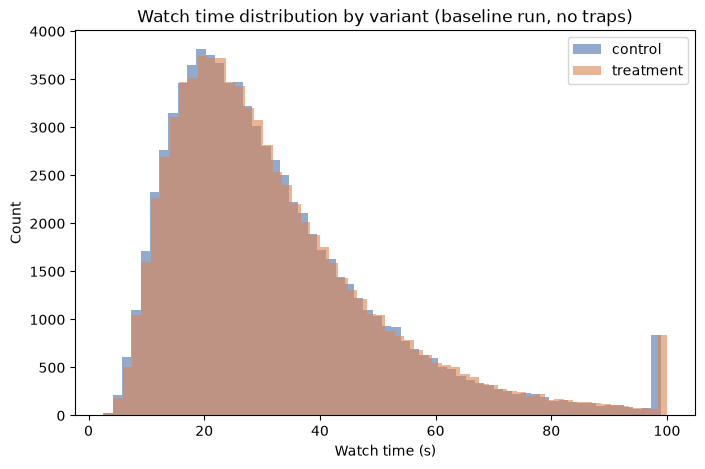

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for variant, color in [("control", "#4C72B0"), ("treatment", "#DD8452")]:
    subset = events.loc[events["variant"] == variant, "watch_time"]
    ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=60, alpha=0.6, color=color, label=variant)
ax.set_xlabel("Watch time (s)")
ax.set_ylabel("Count")
ax.set_title("Watch time distribution by variant (baseline run, no traps)")
ax.legend()

save_fig("simulator_watch_time_by_variant", fig)
plt.show()


## Does the segment effect show up where I planted it?

`day_new` should show the biggest lift, `30day_retention` the smallest, since that's the
multiplier I set on each segment. This is the exact pattern Phase 4's uplift model is
supposed to recover on its own, so I want to confirm it's actually there in the data it'll
be trained on.


In [9]:
segment_lift = (
    events.groupby(["user_segment", "variant"])["watch_time"]
    .mean()
    .unstack("variant")
)
segment_lift["lift"] = segment_lift["treatment"] / segment_lift["control"] - 1
segment_lift = segment_lift.sort_values("lift", ascending=False)
segment_lift


variant,control,treatment,lift
user_segment,,,
new_active,22.907568,23.577891,0.029262
day_new,17.203002,17.697219,0.028729
low_active,25.478711,26.171298,0.027183
middle_active,28.268128,28.781357,0.018156
full_active,39.844688,40.241329,0.009955
high_active,34.043162,34.355357,0.009171
30day_retention,45.902995,45.112396,-0.017223


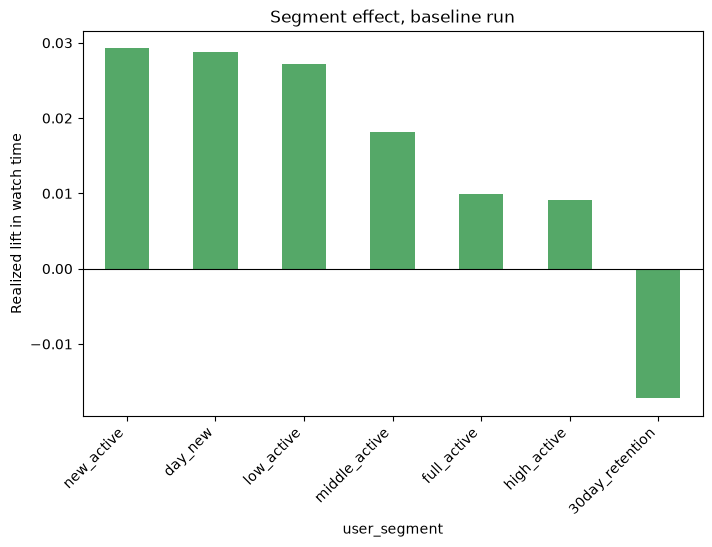

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
segment_lift["lift"].plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("Realized lift in watch time")
ax.set_title("Segment effect, baseline run")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")

save_fig("simulator_segment_lift", fig)
plt.show()


The ranking here should roughly follow the `segment_effect_multiplier` I set in
`core/simulator.py`: `day_new` and `new_active` on top, `30day_retention` at the bottom.
With real sampling noise in a single run, I wouldn't expect it to match the multiplier
ranking exactly for every segment, just the overall shape.


## A/A mode: does the effect actually disappear?

If I zero out the treatment effect, any "lift" I see should just be noise, centered
somewhere around zero.


In [11]:
aa_config = SimulatorConfig(n_users=20_000, experiment_days=14)
aa_events, aa_truth = simulate_aa_experiment(aa_config)

aa_mean = aa_events.groupby("variant")["watch_time"].mean()
aa_lift = aa_mean["treatment"] / aa_mean["control"] - 1

print("A/A ground truth true_effect_pct:", aa_truth["true_effect_pct"])
print(aa_mean)
print(f"Realized lift under A/A: {aa_lift:.3%}")


A/A ground truth true_effect_pct: 0.0
variant
control      31.962138
treatment    31.951415
Name: watch_time, dtype: float64
Realized lift under A/A: -0.034%


Close to zero, as expected, some noise either direction is normal here. This is what
`notebooks/03_coverage_and_aa.ipynb` leans on in Phase 3: run this many times and confirm
roughly 5% of them falsely call a winner at the 95% confidence level.


## Reproducibility: same seed, same data

I want to confirm the simulator is actually deterministic before I rely on it for anything
test-driven.


In [12]:
events_repeat, _ = simulate_experiment(config)
print("Identical on rerun with the same seed:", events.equals(events_repeat))

different_seed_config = SimulatorConfig(n_users=20_000, experiment_days=14, seed=123)
events_different_seed, _ = simulate_experiment(different_seed_config)
print("Different with a different seed:", not events.equals(events_different_seed))


Identical on rerun with the same seed: True
Different with a different seed: True


## Trap 1: Sample ratio mismatch

Skewing assignment to 55/45 instead of 50/50. A chi-square SRM check in Phase 3 should
flag this; here I just want to see the skew actually exists in the output.


In [13]:
srm_config = SimulatorConfig(n_users=20_000, experiment_days=14)
srm_config.traps.srm_treatment_share = 0.55
srm_events, srm_truth = simulate_experiment(srm_config)

print("n_treatment_users:", srm_truth["n_treatment_users"])
print("n_control_users:", srm_truth["n_control_users"])
print(f"Treatment share: {srm_truth['n_treatment_users'] / srm_config.n_users:.3%}")


n_treatment_users: 10972
n_control_users: 9028
Treatment share: 54.860%


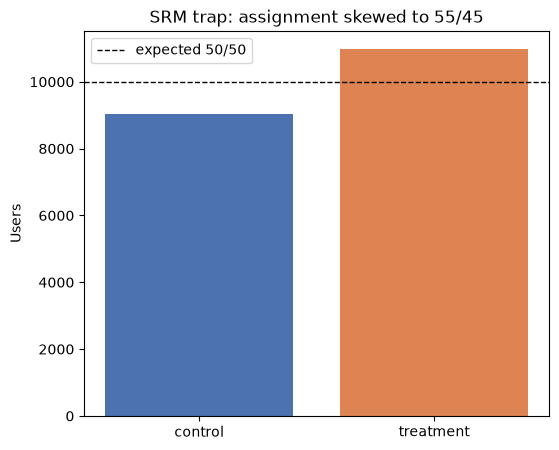

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(
    ["control", "treatment"],
    [srm_truth["n_control_users"], srm_truth["n_treatment_users"]],
    color=["#4C72B0", "#DD8452"],
)
ax.axhline(srm_config.n_users / 2, color="black", linestyle="--", linewidth=1, label="expected 50/50")
ax.set_ylabel("Users")
ax.set_title("SRM trap: assignment skewed to 55/45")
ax.legend()

save_fig("simulator_srm_trap", fig)
plt.show()


## Trap 2: Novelty decay

The treatment effect starts at the full planted size and decays to zero by the last day of
the experiment, instead of staying constant.


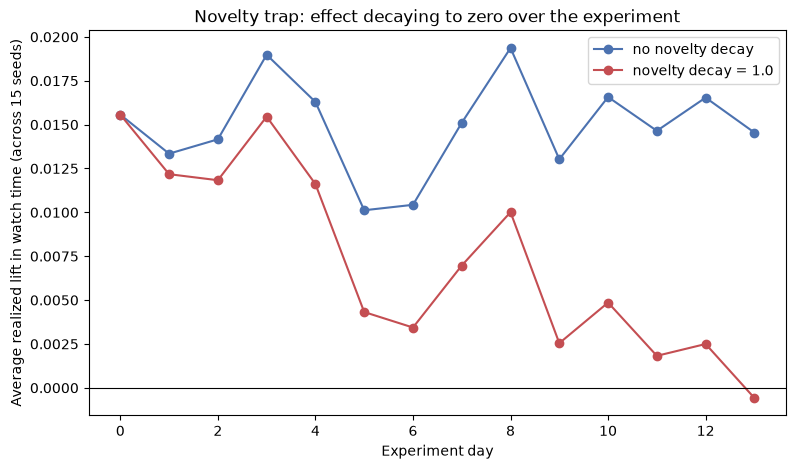

In [15]:
def average_daily_lift(novelty_decay: float, n_reps: int = 15, n_users: int = 20_000, days: int = 14):
    """Average the daily treatment/control lift across several seeds, so the
    day-to-day sampling noise averages out and the underlying shape (flat, or
    decaying) actually becomes visible. A single run is too noisy at this
    sample size to show the decay clearly."""
    lifts = []
    for seed in range(n_reps):
        cfg = SimulatorConfig(n_users=n_users, experiment_days=days, seed=seed)
        cfg.traps.novelty_decay = novelty_decay
        ev, _ = simulate_experiment(cfg)
        daily = ev.groupby(["date", "variant"])["watch_time"].mean().unstack("variant")
        daily["lift"] = daily["treatment"] / daily["control"] - 1
        lifts.append(daily["lift"].values)
    return np.mean(lifts, axis=0)


no_decay_lift = average_daily_lift(novelty_decay=0.0)
decay_lift = average_daily_lift(novelty_decay=1.0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(no_decay_lift)), no_decay_lift, marker="o", label="no novelty decay", color="#4C72B0")
ax.plot(range(len(decay_lift)), decay_lift, marker="o", label="novelty decay = 1.0", color="#C44E52")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Experiment day")
ax.set_ylabel("Average realized lift in watch time (across 15 seeds)")
ax.set_title("Novelty trap: effect decaying to zero over the experiment")
ax.legend()

save_fig("simulator_novelty_trap", fig)
plt.show()


With decay on, the averaged lift starts out close to the no-decay line and trends down
toward zero by the final day. I had to average across several seeds to see this cleanly,
a single run at this sample size is too noisy day to day to show the shape on its own,
which is itself worth remembering: a one-off daily reading can look like anything.


## Trap 3: Broken guardrail (retention drop)

Watch time while active still improves, but treatment users come back less often the next
day. This is the trap Phase 3B's decision system is supposed to catch as a HOLD instead of
a SHIP, even though the headline metric looks good.


In [16]:
retention_config = SimulatorConfig(n_users=20_000, experiment_days=14)
retention_config.traps.retention_drop = 0.08
retention_events, retention_truth = simulate_experiment(retention_config)

def daily_retention_by_variant(events_df: pd.DataFrame) -> pd.DataFrame:
    """Day-over-day return rate per variant: of the users active on day N, what share
    are still active on day N+1?"""
    dates = sorted(events_df["date"].unique())
    rows = []
    for variant in ["control", "treatment"]:
        for i in range(len(dates) - 1):
            today_users = set(
                events_df.loc[
                    (events_df["date"] == dates[i]) & (events_df["variant"] == variant),
                    "user_id",
                ]
            )
            tomorrow_users = set(
                events_df.loc[events_df["date"] == dates[i + 1], "user_id"]
            )
            if not today_users:
                continue
            retained = len(today_users & tomorrow_users) / len(today_users)
            rows.append({"date": dates[i], "variant": variant, "retention": retained})
    return pd.DataFrame(rows)


baseline_retention = daily_retention_by_variant(events)
broken_retention = daily_retention_by_variant(retention_events)

print("Average next-day retention, baseline run:")
print(baseline_retention.groupby("variant")["retention"].mean())
print()
print("Average next-day retention, retention-drop trap on:")
print(broken_retention.groupby("variant")["retention"].mean())


Average next-day retention, baseline run:
variant
control      0.550415
treatment    0.550509
Name: retention, dtype: float64

Average next-day retention, retention-drop trap on:
variant
control      0.550746
treatment    0.468059
Name: retention, dtype: float64


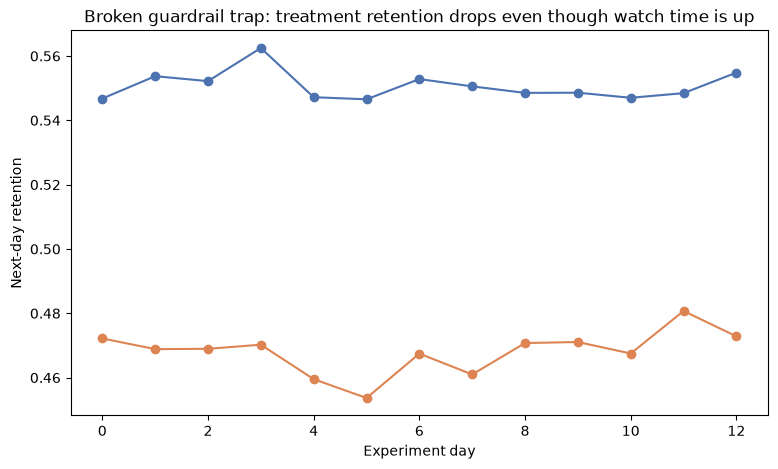


Watch time still looks like a win, by the way:
variant
control      31.830375
treatment    32.483632
Name: watch_time, dtype: float64
Lift: 2.052%


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
for variant, color in [("control", "#4C72B0"), ("treatment", "#DD8452")]:
    subset = broken_retention[broken_retention["variant"] == variant]
    ax.plot(range(len(subset)), subset["retention"].values, marker="o", color=color, label=variant)
ax.set_xlabel("Experiment day")
ax.set_ylabel("Next-day retention")
ax.set_title("Broken guardrail trap: treatment retention drops even though watch time is up")

save_fig("simulator_retention_drop_trap", fig)
plt.show()

mean_watch_time_broken = retention_events.groupby("variant")["watch_time"].mean()
print()
print("Watch time still looks like a win, by the way:")
print(mean_watch_time_broken)
print(f"Lift: {mean_watch_time_broken['treatment'] / mean_watch_time_broken['control'] - 1:.3%}")


That's the trap: watch time is up, but treatment users are coming back less, which is
exactly the scenario a decision rule that only looks at the primary metric would get wrong.


## Trap 4: Spillover

A slice of the control group is secretly exposed to the treatment effect anyway (think: a
user whose friend got the new ranking model and shared a clip from it). I can't flag which
specific control rows are contaminated in the output, since a real analyst would never have
that information either, that's what makes spillover hard to catch. What I can do is
compare the control group's average watch time between a clean run and a spillover run with
the same seed: if spillover is inflating control, its average should drift upward.


In [18]:
spillover_config = SimulatorConfig(n_users=20_000, experiment_days=14)
spillover_config.traps.spillover_fraction = 0.15
spillover_config.traps.spillover_strength = 0.5
spillover_events, spillover_truth = simulate_experiment(spillover_config)

clean_control_mean = events.loc[events["variant"] == "control", "watch_time"].mean()
spillover_control_mean = spillover_events.loc[spillover_events["variant"] == "control", "watch_time"].mean()

print(f"Control mean watch time, no spillover: {clean_control_mean:.3f}")
print(f"Control mean watch time, spillover trap on: {spillover_control_mean:.3f}")
print(f"Contaminated control users: {spillover_truth['n_spillover_contaminated_control_users']}")

clean_lift = (
    events.groupby("variant")["watch_time"].mean()["treatment"] / clean_control_mean - 1
)
spillover_measured_lift = (
    spillover_events.groupby("variant")["watch_time"].mean()["treatment"]
    / spillover_control_mean
    - 1
)
print()
print(f"Measured lift, no spillover: {clean_lift:.3%}")
print(f"Measured lift, spillover trap on: {spillover_measured_lift:.3%}")


Control mean watch time, no spillover: 31.962
Control mean watch time, spillover trap on: 31.999
Contaminated control users: 1531

Measured lift, no spillover: 1.471%
Measured lift, spillover trap on: 1.354%


With spillover on, control's average should sit a little higher than the clean run, and
the measured treatment-versus-control lift should come out smaller than the true 2% I
planted, even though the real per-user effect never changed. That understatement is exactly
what makes spillover dangerous: the experiment looks less effective than it actually is,
and nothing about the numbers themselves says why.


## Saving a summary table

In [19]:
trap_summary = pd.DataFrame([
    {
        "trap": "none (baseline)",
        "realized_lift": realized_lift,
        "n_treatment": truth["n_treatment_users"],
        "n_control": truth["n_control_users"],
    },
    {
        "trap": "A/A (effect zeroed)",
        "realized_lift": aa_lift,
        "n_treatment": aa_truth["n_treatment_users"],
        "n_control": aa_truth["n_control_users"],
    },
    {
        "trap": "SRM (55/45 split)",
        "realized_lift": np.nan,
        "n_treatment": srm_truth["n_treatment_users"],
        "n_control": srm_truth["n_control_users"],
    },
    {
        "trap": "retention drop (0.08)",
        "realized_lift": (
            mean_watch_time_broken["treatment"] / mean_watch_time_broken["control"] - 1
        ),
        "n_treatment": retention_truth["n_treatment_users"],
        "n_control": retention_truth["n_control_users"],
    },
    {
        "trap": "spillover (0.15 frac, 0.5 strength)",
        "realized_lift": spillover_measured_lift,
        "n_treatment": spillover_truth["n_treatment_users"],
        "n_control": spillover_truth["n_control_users"],
    },
])

trap_summary
save_table("simulator_trap_summary", trap_summary)


WindowsPath('C:/Users/sabin/splitlab/docs/tables/simulator_trap_summary.csv')

## Where this leaves me

The simulator behaves the way `core/simulator.py` claims it does:

- The planted 2% watch-time effect shows up in the realized data at roughly the right size.
- The segment effect follows the ranking I set, newer users benefit more.
- A/A mode genuinely zeroes the effect out, leaving only noise.
- Same seed gives identical output every time; a different seed gives different output.
- All five traps behave as designed: SRM skews the split, novelty decays the effect to zero
  by the end of the experiment, the broken guardrail trap drops retention while watch time
  still looks like a win, and spillover quietly inflates the control group and understates
  the measured effect.